# Per-Gene Population Evaluation

How well is each gene reconstructed across GTEx samples?

1. **Section 1** — overall: ranked curve + histogram across all samples, one line per model.
2. **Section 2** — tissue-stratified: ranked curve + histogram with one line per tissue (single model) and a per-tissue × per-model heat in the table.

The gene panel is set in **one place** (`GENE_LIST_PATH` mini-config) and threaded through both sections, so swapping the panel only requires editing that one cell + re-running the compute cell.


## Table of Contents

- Notebook Configuration
- Shared Reconstruction
- Section 1 — Overall (all GTEx samples)
- Section 2 — Tissue-stratified
- Section 3 — Gene-sublist scatter (3 models)
- Section 4 — Interactive single-gene scatter
- Section 5 — Within-subject spatial Kendall-τ


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as _np

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
%matplotlib inline

import importlib
import src.eval_utils.eval_style as eval_style
import src.eval_utils.eda_core as eda_core
import src.eval_utils.eval_population as eval_population
importlib.reload(eval_style)
importlib.reload(eda_core)
importlib.reload(eval_population)
from src.eval_utils.eval_style import *
from src.eval_utils.eval_population import *

## Notebook Configuration

Global / cross-section knobs in the next cell. Per-section knobs live in mini-config cells immediately above their use sites.


In [ ]:
# === Global config ===
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    cache_root='out/loro_subject_cache_c',  # 'out/loro_subject_cache_c' (centroids) | 'out/loro_subject_cache_cv' (centroids_and_volumes)
    gene_scope='allgenes',
)
print('analysis scope:', CFG.gene_scope)

MODELS                       = ['naive', 'dlam', 'plam']
N_JOBS                       = 16
CACHE_GLOBAL_TABLES          = True
FORCE_REBUILD_GLOBAL_TABLES  = True

VIEW_SUBSET = dict(
    genes=None, subjects=None, tissues=None,
    region_groups=None, sex=None, age=None,
)

DEFAULT_METRIC               = 'pearson_r'   # pearson_r | spearman_r | r2 | rmse

analysis scope: allgenes


## Shared Reconstruction

`PREPOST` + canonical wide truth/pred tables. The view used for the per-gene scoring is constructed in **Section 1** below using `GENE_LIST_PATH` so swapping panels is a single-cell edit.


In [4]:
PREPOST = prepare_pre_post_harmonization_cached(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])

[prepost_cache] hit  notebooks/cache/prepost/d1d561fb0d88c15e.pkl  (10426.1 MB)
subjects: 318
genes: 13618
parcels: 150


In [5]:
truth_df, pred_dfs, global_manifest = build_global_prediction_tables(
    cfg=CFG,
    prepost=PREPOST,
    models=MODELS,
    cache=CACHE_GLOBAL_TABLES,
    force_rebuild=FORCE_REBUILD_GLOBAL_TABLES,
    n_jobs=N_JOBS,
)
print({model: df.shape for model, df in pred_dfs.items()})

{'naive': (2820, 13636), 'dlam': (2820, 13636), 'plam': (2820, 13636)}


In [6]:
# Helper: build a gene-panel-scoped view from globals (truth_df / pred_dfs / VIEW_SUBSET).
# Keeps each section's setup to a single line.
def build_panel_view(gene_list_path=None, models=None, **overrides):
    subset = {**VIEW_SUBSET, **overrides}
    return make_prediction_eval_view(
        truth_df=truth_df, pred_dfs=pred_dfs,
        eval_gene_list_path=gene_list_path,
        models=list(models) if models is not None else MODELS,
        **subset,
    )


## Section 1 — Overall (all GTEx samples)

One ranked curve and one histogram across **all GTEx samples**, with one line per model. The gene panel is set once at the top of this section and reused by Section 2.


In [ ]:
# Section 1 config — gene panel + compute knobs (shared with Section 2)
GENE_LIST_PATH       = None # 'gtex_100hvg'                # None = all genes; e.g. 'gtex_100hvg', 'syngo', 'richiardi2015', or a path
GENEWISE_METRICS     = ['pearson_r', 'r2', 'rmse']
GENEWISE_N_JOBS      = N_JOBS

# Plot knobs (overall view)
GENEWISE_RANKED_METRIC          = DEFAULT_METRIC
GENEWISE_RANKED_ANCHOR_MODEL    = 'dlam'
GENEWISE_RANKED_LABEL_STEP_PCT  = 10.0    # label one anchor-model gene per 10%; None = no top labels
GENEWISE_LABELED_GENES          = None    # explicit callouts, e.g. ['PVALB', 'GFAP', 'SLC17A7']
GENEWISE_HIST_BINS              = 60
GENEWISE_HIST_ALPHA             = 0.42


In [8]:
# Build the gene-panel-scoped view + compute genewise metrics across ALL samples (no stratification).
genewise_view = build_panel_view(GENE_LIST_PATH)
print('view genes:', len(genewise_view['genes']))

genewise_df = compute_genewise_metrics(
    genewise_view,
    models=MODELS,
    metrics=GENEWISE_METRICS,
    n_jobs=GENEWISE_N_JOBS,
)
print('genewise_df:', genewise_df.shape)
display(
    genewise_df.groupby('model', as_index=False).agg(
        n_genes=('gene', 'nunique'),
        n_samples=('n_samples', 'first'),
        median_pearson=('pearson_r', 'median'),
        median_r2=('r2', 'median'),
        median_rmse=('rmse', 'median'),
    )
)


view genes: 100
genewise_df: (300, 11)


,model,n_genes,n_samples,median_pearson,median_r2,median_rmse
0,dlam,100,2820,0.603552,0.271777,0.644845
1,naive,100,2820,0.530280,-0.854465,1.328429
2,plam,100,2820,0.435472,-0.371467,1.024179


### Ranked curve

Genes are sorted worst → best within each model and plotted by rank percentile. Anchor-model gene names sit on the curve at every `GENEWISE_RANKED_LABEL_STEP_PCT`-th percentile; pass `GENEWISE_LABELED_GENES=[...]` to add explicit callouts.


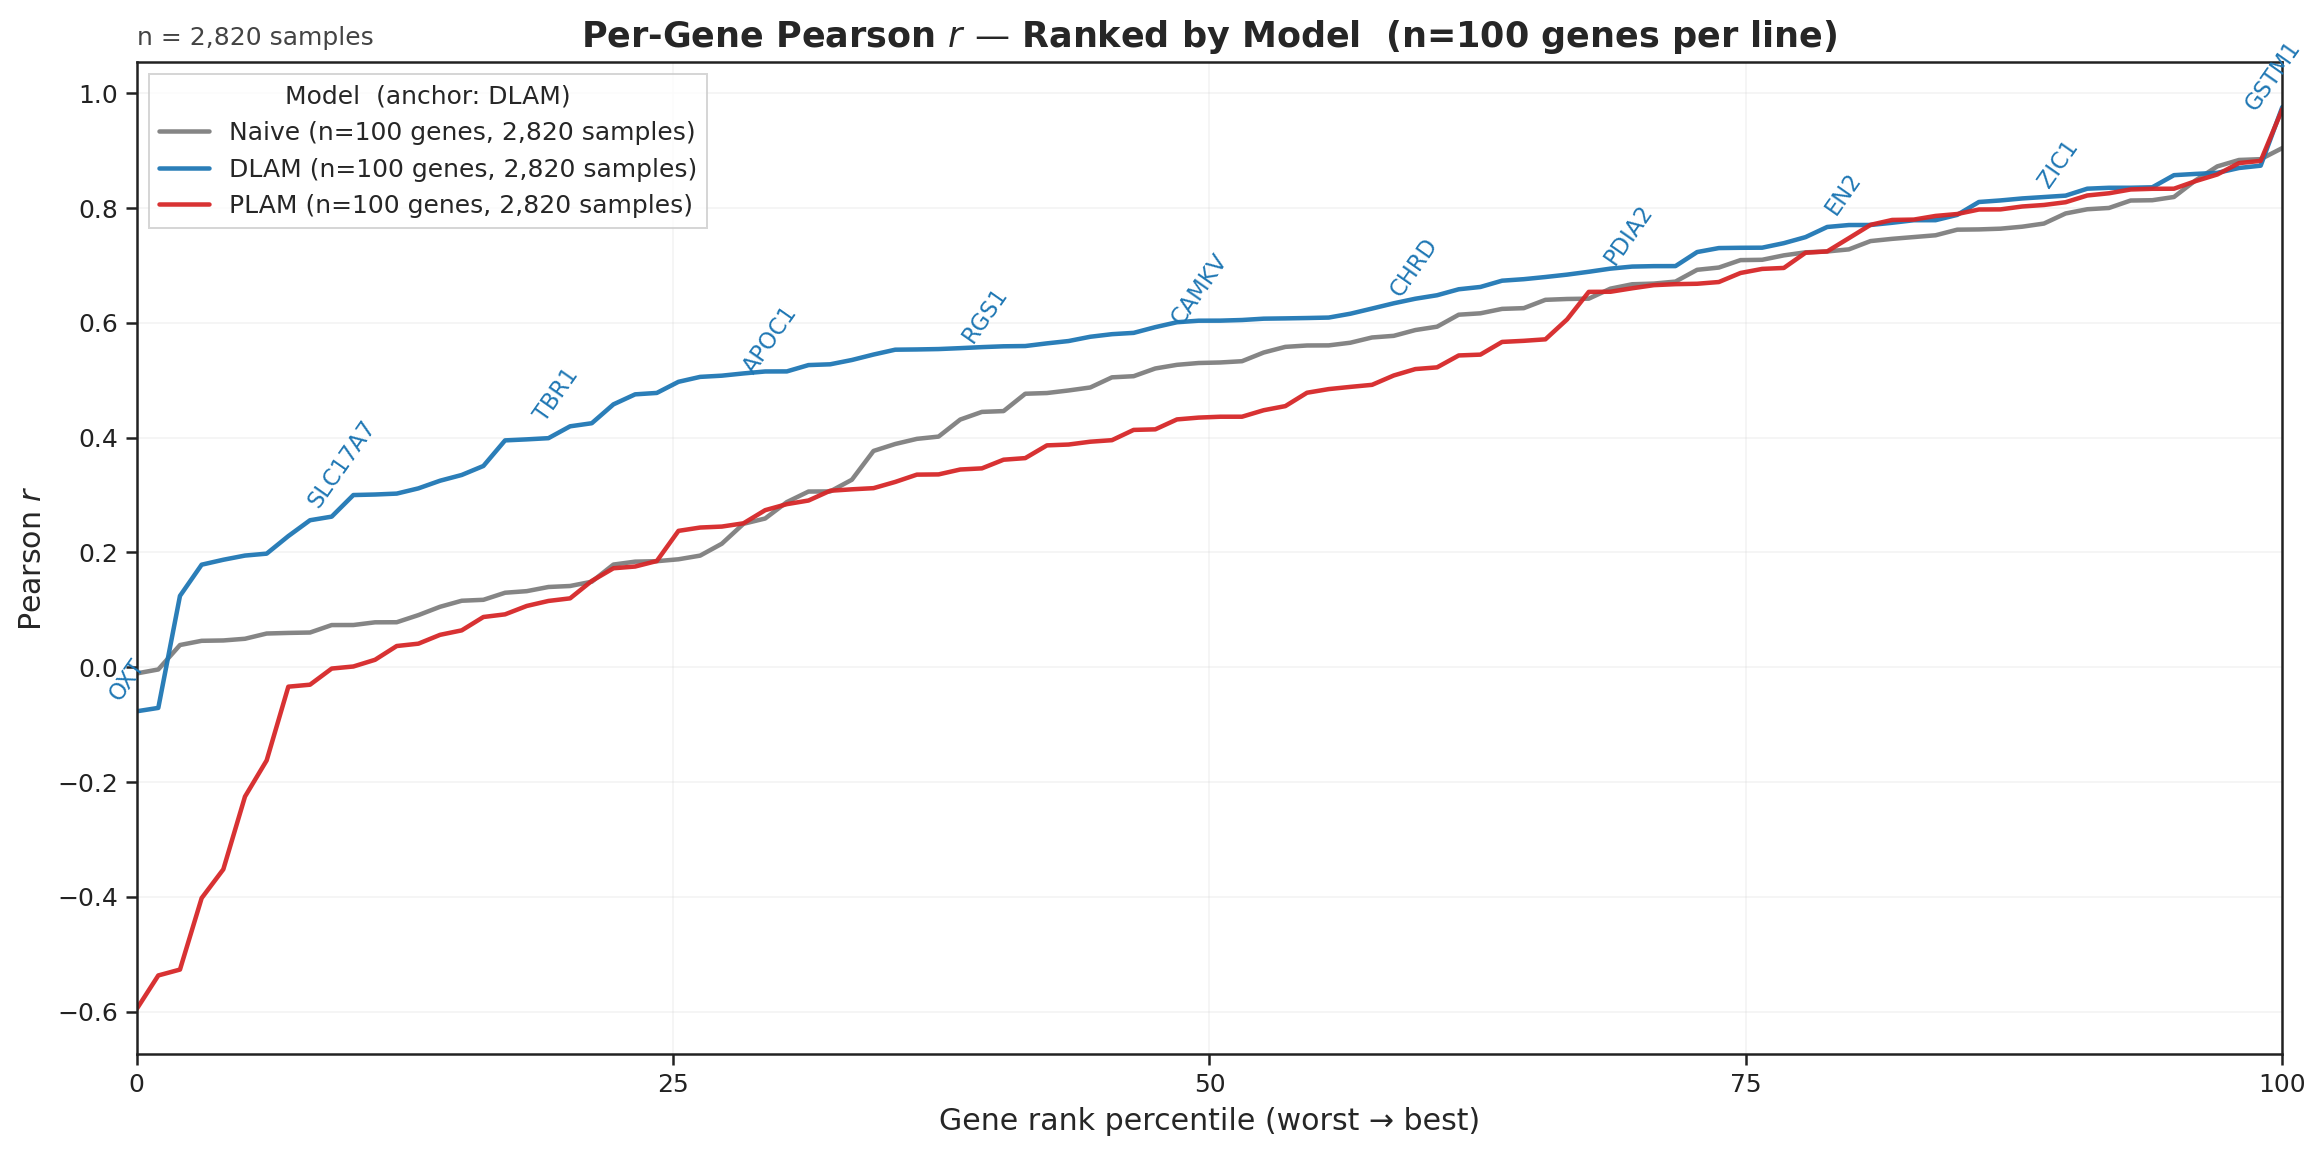

In [9]:
fig, ax, ranked_genewise = plot_genewise_ranked_overlay(
    genewise_df,
    metric=GENEWISE_RANKED_METRIC,
    group_by='model',
    groups=MODELS,
    anchor=GENEWISE_RANKED_ANCHOR_MODEL,
    gene_label_step_pct=GENEWISE_RANKED_LABEL_STEP_PCT,
    labeled_genes=GENEWISE_LABELED_GENES,
)

### Histogram

Overlapping per-model distributions of the per-gene metric, with each model's median as a dashed rule.


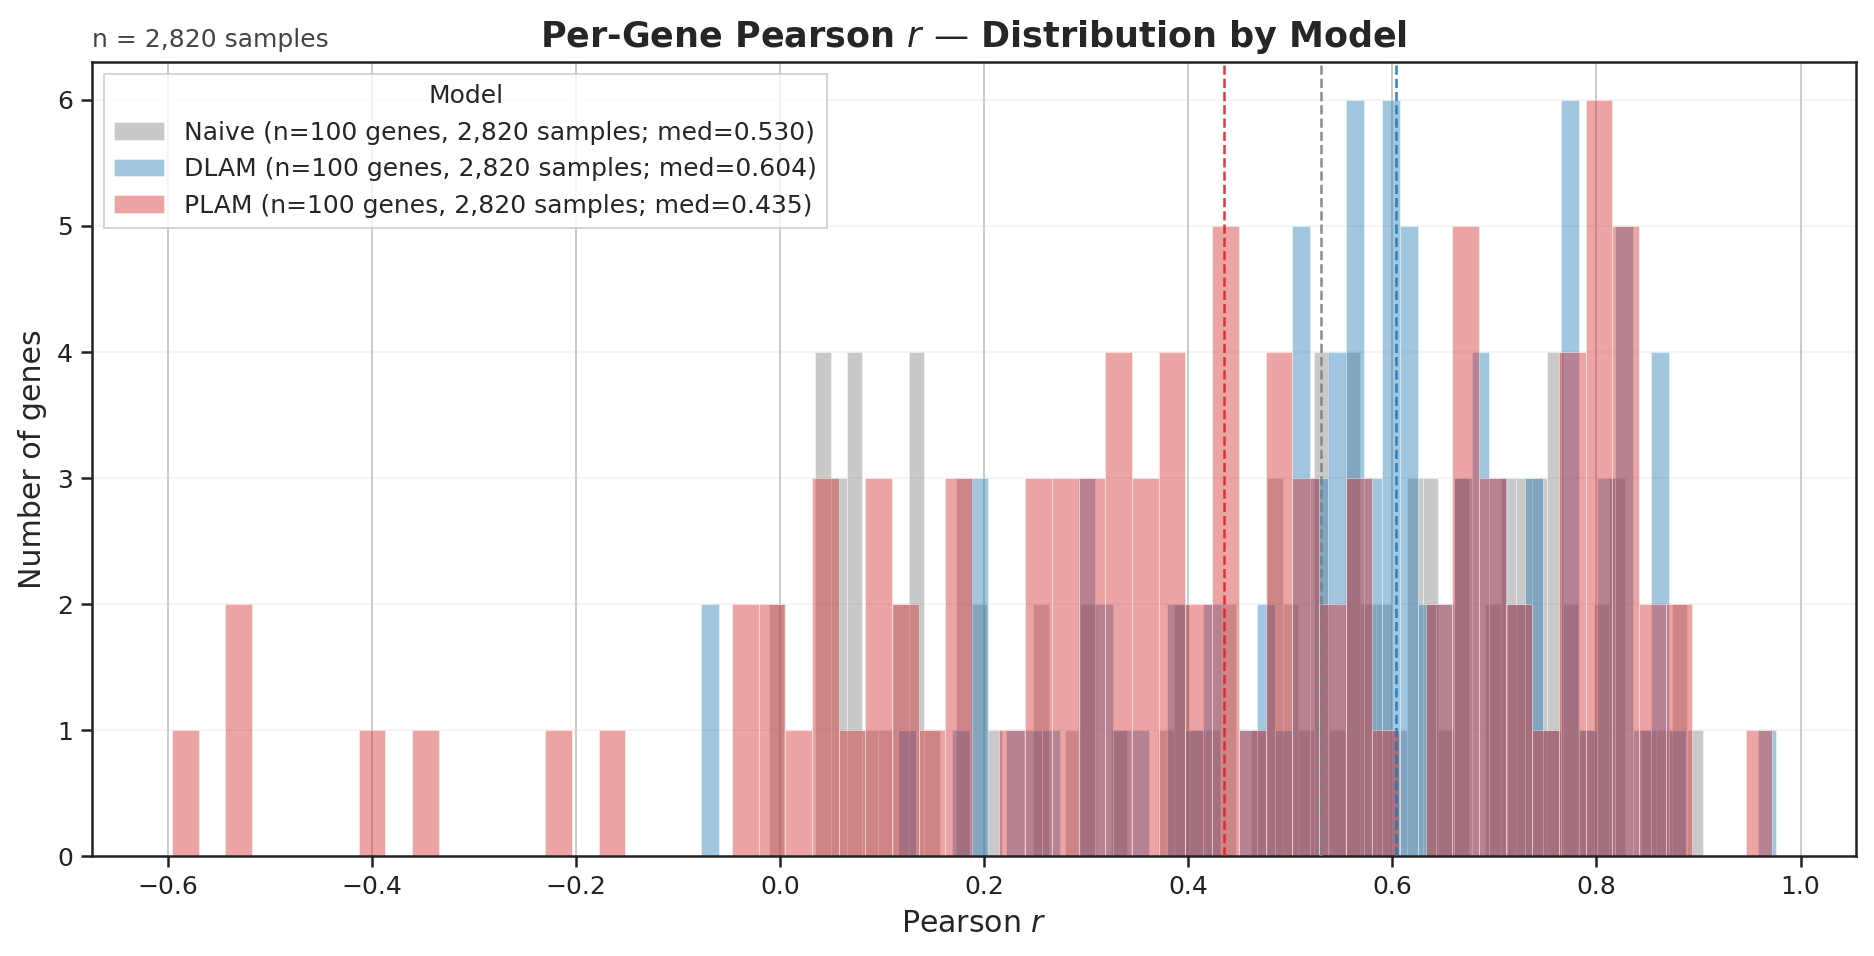

In [10]:
fig, ax = plot_genewise_histogram(
    genewise_df,
    metric=GENEWISE_RANKED_METRIC,
    group_by='model',
    groups=MODELS,
    bins=GENEWISE_HIST_BINS,
    alpha=GENEWISE_HIST_ALPHA,
    show_median=True,
)

## Section 2 — Tissue-stratified

Recompute genewise metrics filtered per GTEx tissue (one row per `(model, gtex_region, gene)`; `n_samples` is per-tissue). Two views:

1. **Single model, ranked by tissue** — one line per tissue using the shared region palette.
2. **Single model, distribution by tissue** — overlapping histograms across tissues.

To inspect a different model swap `TISSUE_VIEW_MODEL`; to restrict to a subset of tissues, set `TISSUE_VIEW_GROUPS` (e.g. `['Brain - Cortex', 'Brain - Cerebellum']`).


In [ ]:
# Section 2 config
TISSUE_VIEW_MODEL          = 'dlam'   # which model's lines to draw
TISSUE_VIEW_GROUPS         = None     # None = all tissues; or list of gtex_region strings
TISSUE_VIEW_LABEL_STEP_PCT = 10.0     # gene labels every 20%; tissues have far fewer genes than the full panel
TISSUE_VIEW_LABELED_GENES  = None

In [12]:
genewise_tissue_df = compute_genewise_metrics(
    genewise_view,
    models=MODELS,
    metrics=GENEWISE_METRICS,
    stratify_by='gtex_region',
    n_jobs=GENEWISE_N_JOBS,
)
print('genewise_tissue_df:', genewise_tissue_df.shape)
display(
    genewise_tissue_df.groupby(['model', 'gtex_region'], as_index=False).agg(
        n_genes=('gene', 'nunique'),
        n_samples=('n_samples', 'first'),
        median=('pearson_r', 'median'),
    ).head(20)
)

genewise_tissue_df: (3600, 13)


,model,gtex_region,n_genes,n_samples,median
0,dlam,brain - amygdala,100,178,0.309085
1,dlam,brain - anterior cingulate cortex (ba24),100,219,0.167504
2,dlam,brain - caudate (basal ganglia),100,274,0.437623
3,dlam,brain - cerebellar hemisphere,100,258,0.299294
4,dlam,brain - cerebellum,100,247,0.217036
5,dlam,brain - cortex,100,236,0.388453
6,dlam,brain - frontal cortex (ba9),100,247,0.360463
7,dlam,brain - hippocampus,100,236,0.244743
8,dlam,brain - hypothalamus,100,238,0.265971
9,dlam,brain - nucleus accumbens (basal ganglia),100,268,0.353223


### Tissue ranked curve (single model)


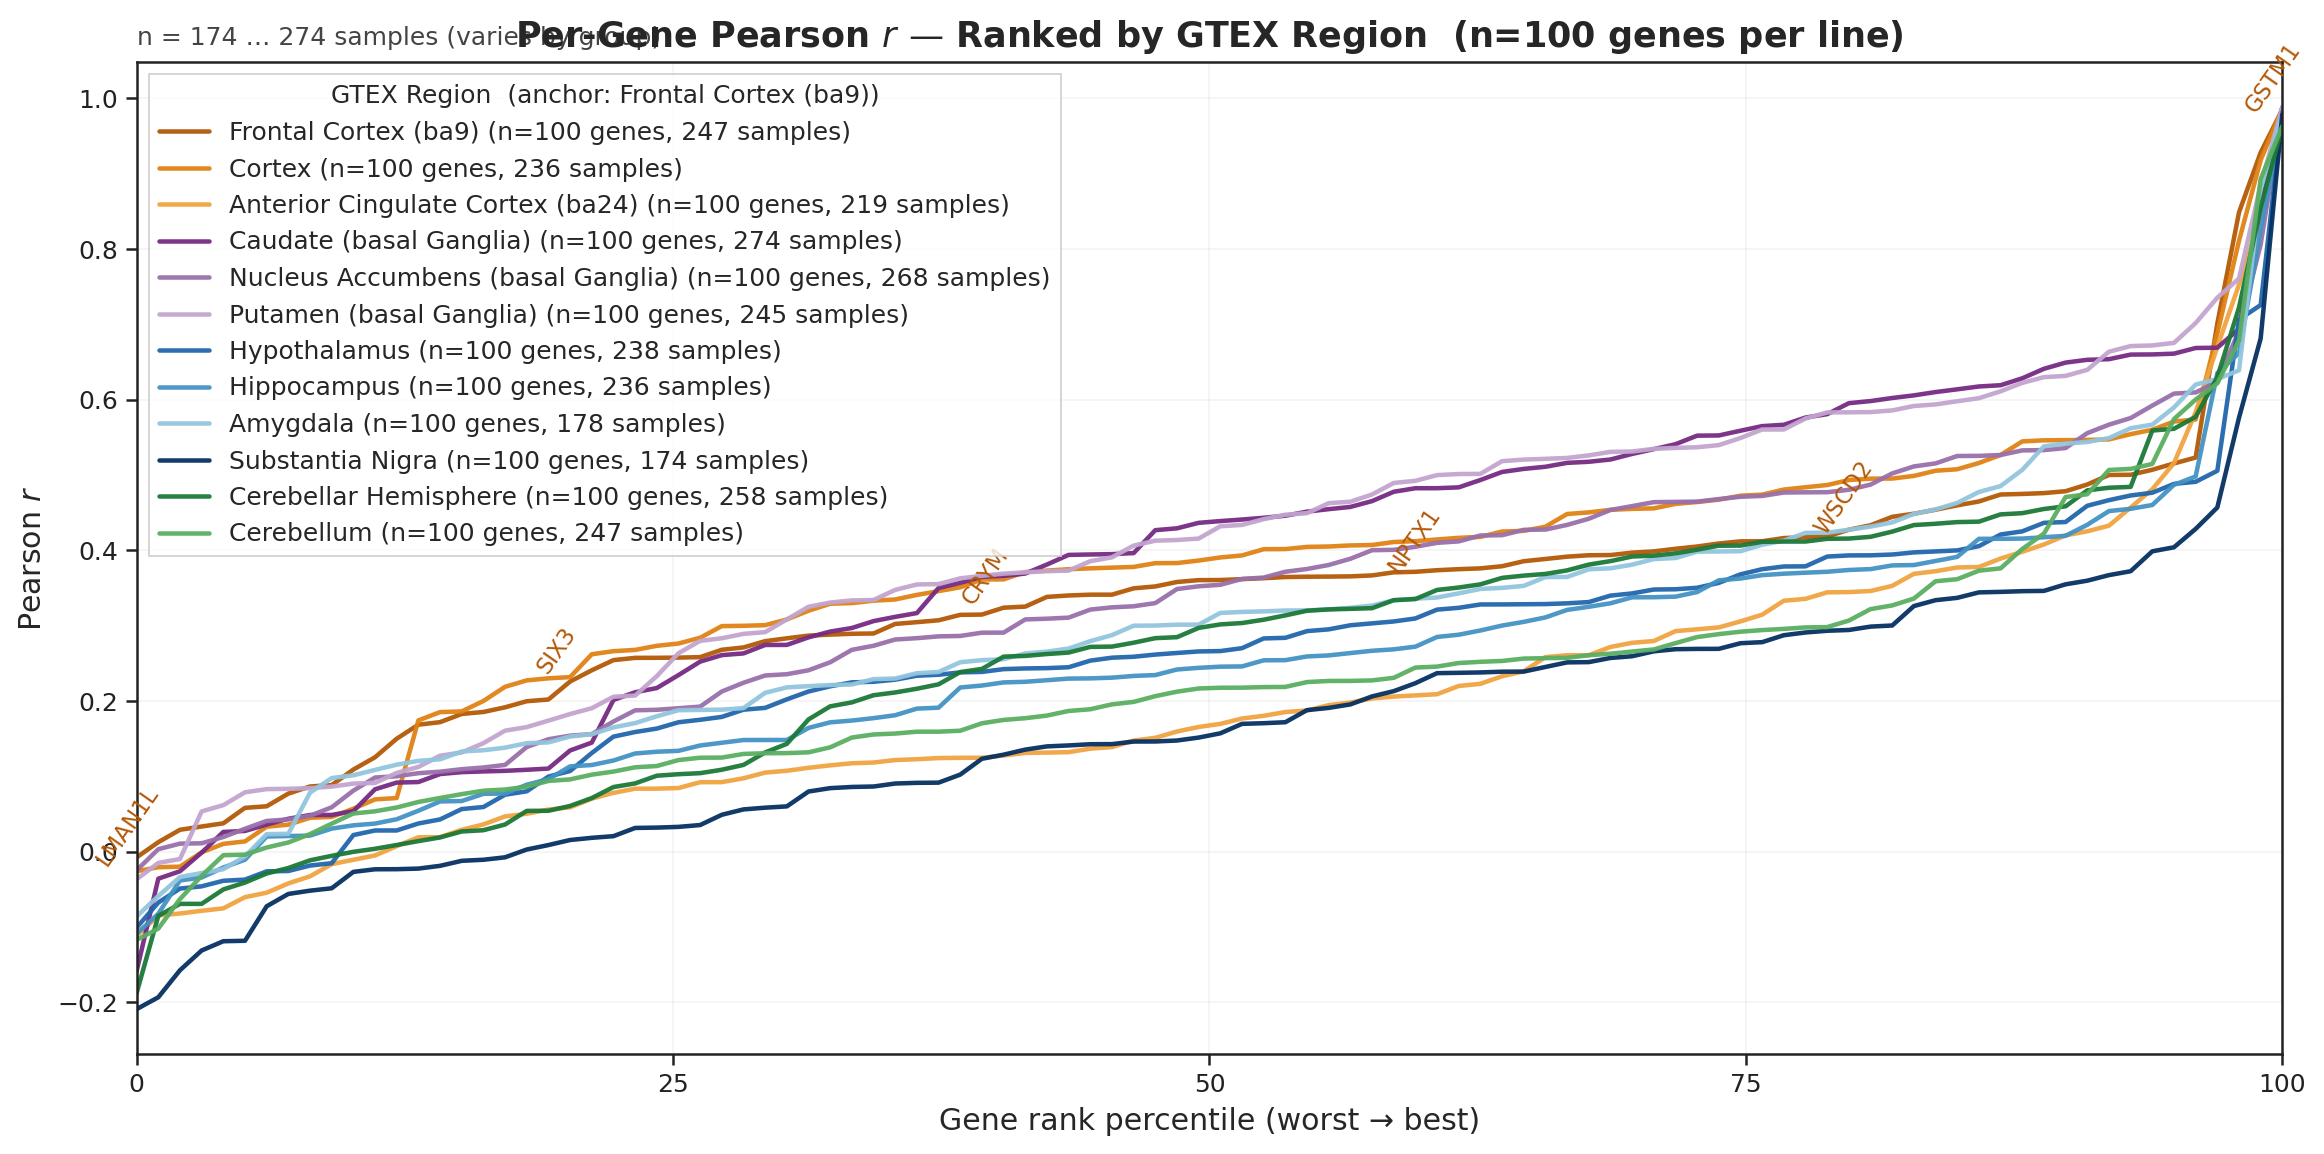

In [13]:
tissue_df_one_model = genewise_tissue_df[
    genewise_tissue_df['model'].astype(str).str.lower() == str(TISSUE_VIEW_MODEL).lower()
]

fig, ax, ranked_tissue = plot_genewise_ranked_overlay(
    tissue_df_one_model,
    metric=GENEWISE_RANKED_METRIC,
    group_by='gtex_region',
    groups=TISSUE_VIEW_GROUPS,
    gene_label_step_pct=TISSUE_VIEW_LABEL_STEP_PCT,
    labeled_genes=TISSUE_VIEW_LABELED_GENES,
)

### Tissue histogram (single model)


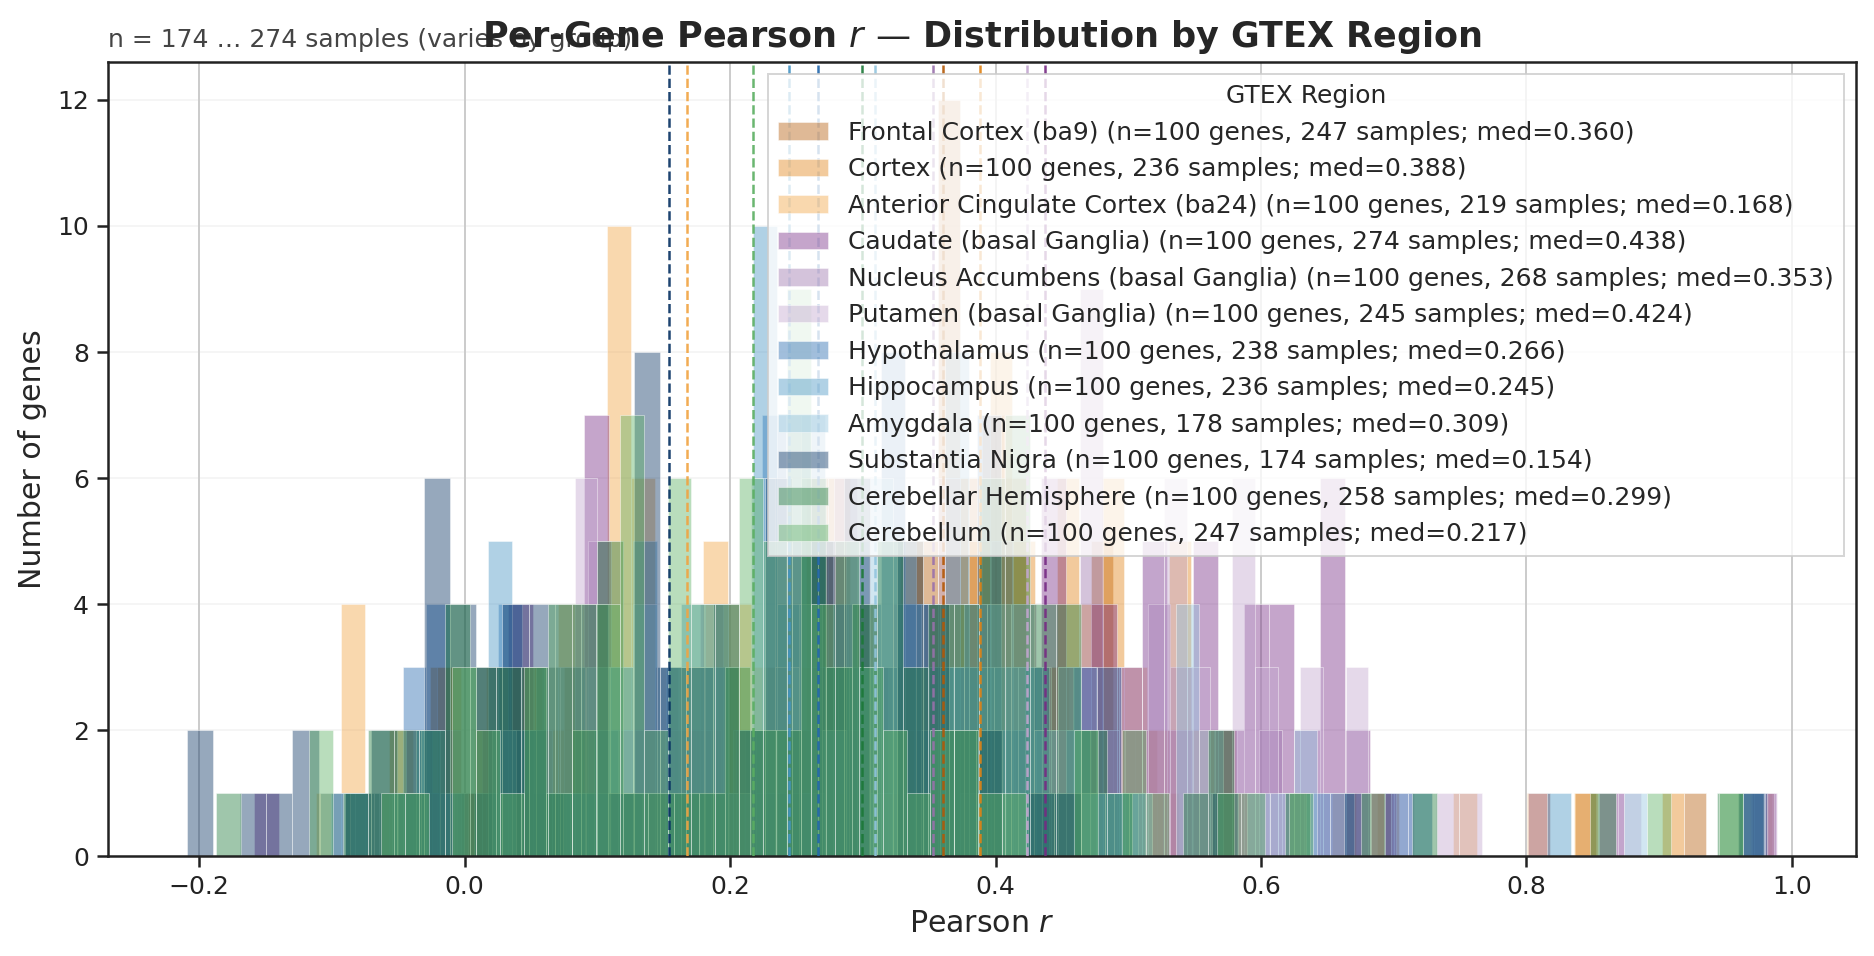

In [14]:
fig, ax = plot_genewise_histogram(
    tissue_df_one_model,
    metric=GENEWISE_RANKED_METRIC,
    group_by='gtex_region',
    groups=TISSUE_VIEW_GROUPS,
    bins=GENEWISE_HIST_BINS,
    alpha=GENEWISE_HIST_ALPHA,
    show_median=True,
)

## Section 3 — Gene-sublist scatter (3 models)

Truth-vs-prediction scatter restricted to a gene-list panel (default: `gtex_100hvg`), one figure per model. Top-N genes get distinct colors with their per-gene `pearson_r` in the legend; the rest fall into transparent gray.

Selection knobs:
- `SUBLIST_SELECTION = 'top' | 'bottom' | 'random' | 'list_order'` — which N genes get colored.
- `SUBLIST_RANK_MODEL` — which model's ranking drives the selection (so the **same** genes color across all 3 panels for direct comparison).
- `SUBLIST_HIGHLIGHT_GENES = ['PVALB','SST','SIX3']` — hard override, picks those exact genes regardless of selection mode.


In [15]:
# Section 3 config — gene-sublist scatter
SUBLIST_GENE_LIST_PATH   = 'gtex_100hvg'   # path/basename of the gene-panel restriction
SUBLIST_TOP_N            = 10              # number of genes to color in the legend
SUBLIST_SELECTION        = 'top'           # 'top' | 'bottom' | 'random' | 'list_order'
SUBLIST_RANK_MODEL       = 'dlam'          # which model's ranking decides the colored set
SUBLIST_RANK_METRIC      = 'pearson_r'     # ranking metric (pearson_r | spearman_r | r2 | rmse)
SUBLIST_HIGHLIGHT_GENES  = None            # e.g. ['PVALB','SST','SIX3'] — overrides selection
SUBLIST_FIGSIZE          = (7.5, 6.5)
SUBLIST_ANNOTATE_METRIC  = 'pearson_r'     # per-gene metric in legend; None = off
SUBLIST_RANDOM_SEED      = 0
SCATTER_MAX_POINTS_PER_MODEL = None        # None = no sub-sampling for the scatter draw


In [16]:
sublist_view = build_panel_view(SUBLIST_GENE_LIST_PATH)
print('sublist view genes:', len(sublist_view['genes']))

# Precompute the per-gene rank lookup ONCE against SUBLIST_RANK_MODEL on the full
# 3-model view, so the same colored gene set is reused across all three single-model
# panels (regardless of which model is in each panel's view).
if SUBLIST_SELECTION in ('top', 'bottom') and not SUBLIST_HIGHLIGHT_GENES:
    sublist_rank_lookup = compute_gene_rank_lookup(
        sublist_view, model=SUBLIST_RANK_MODEL, metric=SUBLIST_RANK_METRIC,
    )
    print(f'rank lookup: {len(sublist_rank_lookup)} genes scored against {SUBLIST_RANK_MODEL}')
else:
    sublist_rank_lookup = None


sublist view genes: 100
rank lookup: 100 genes scored against dlam


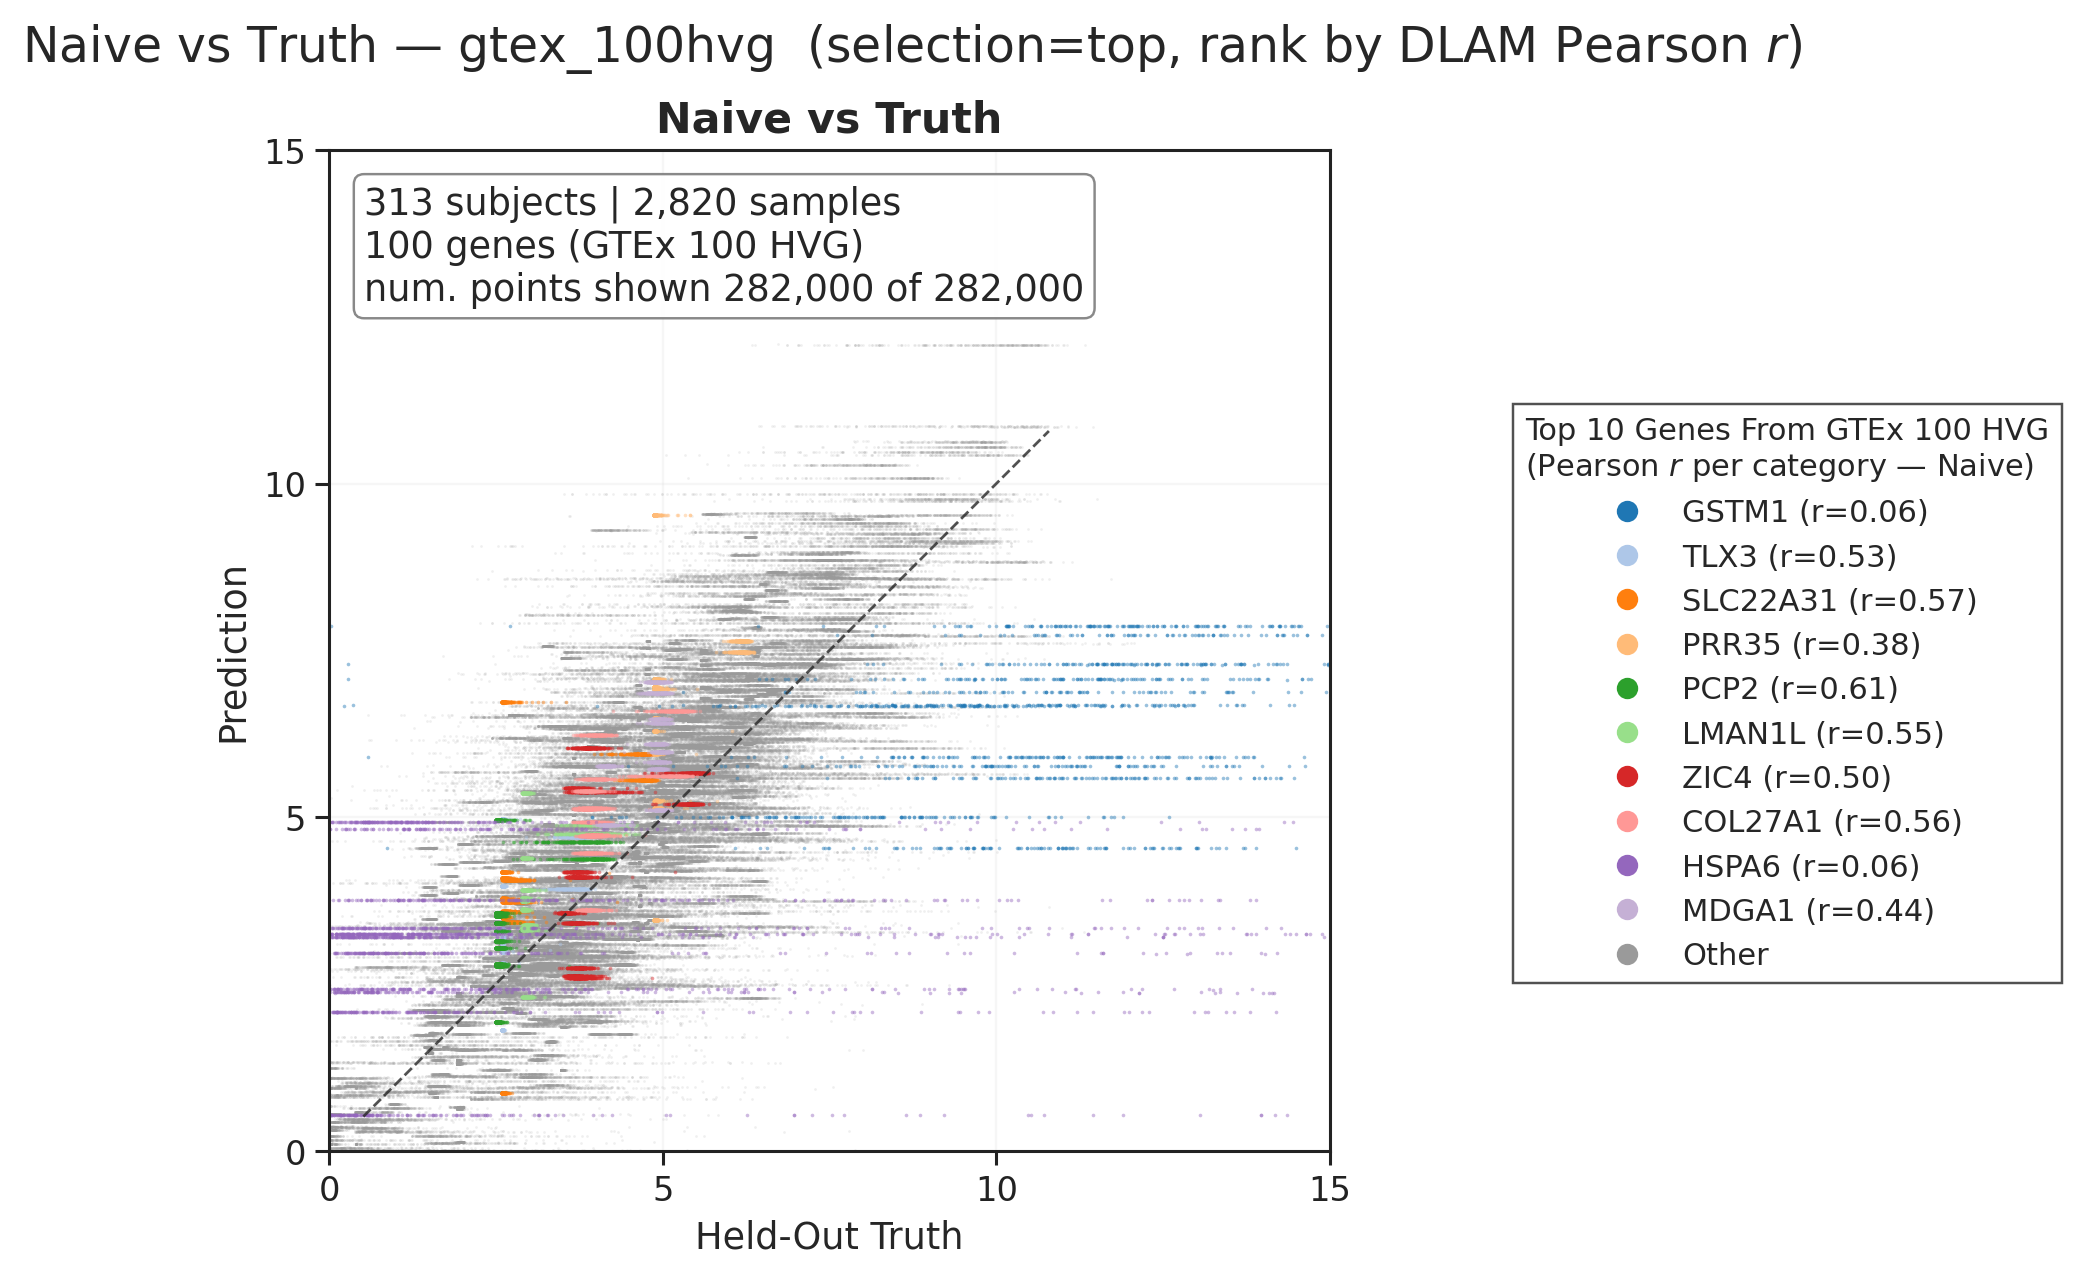

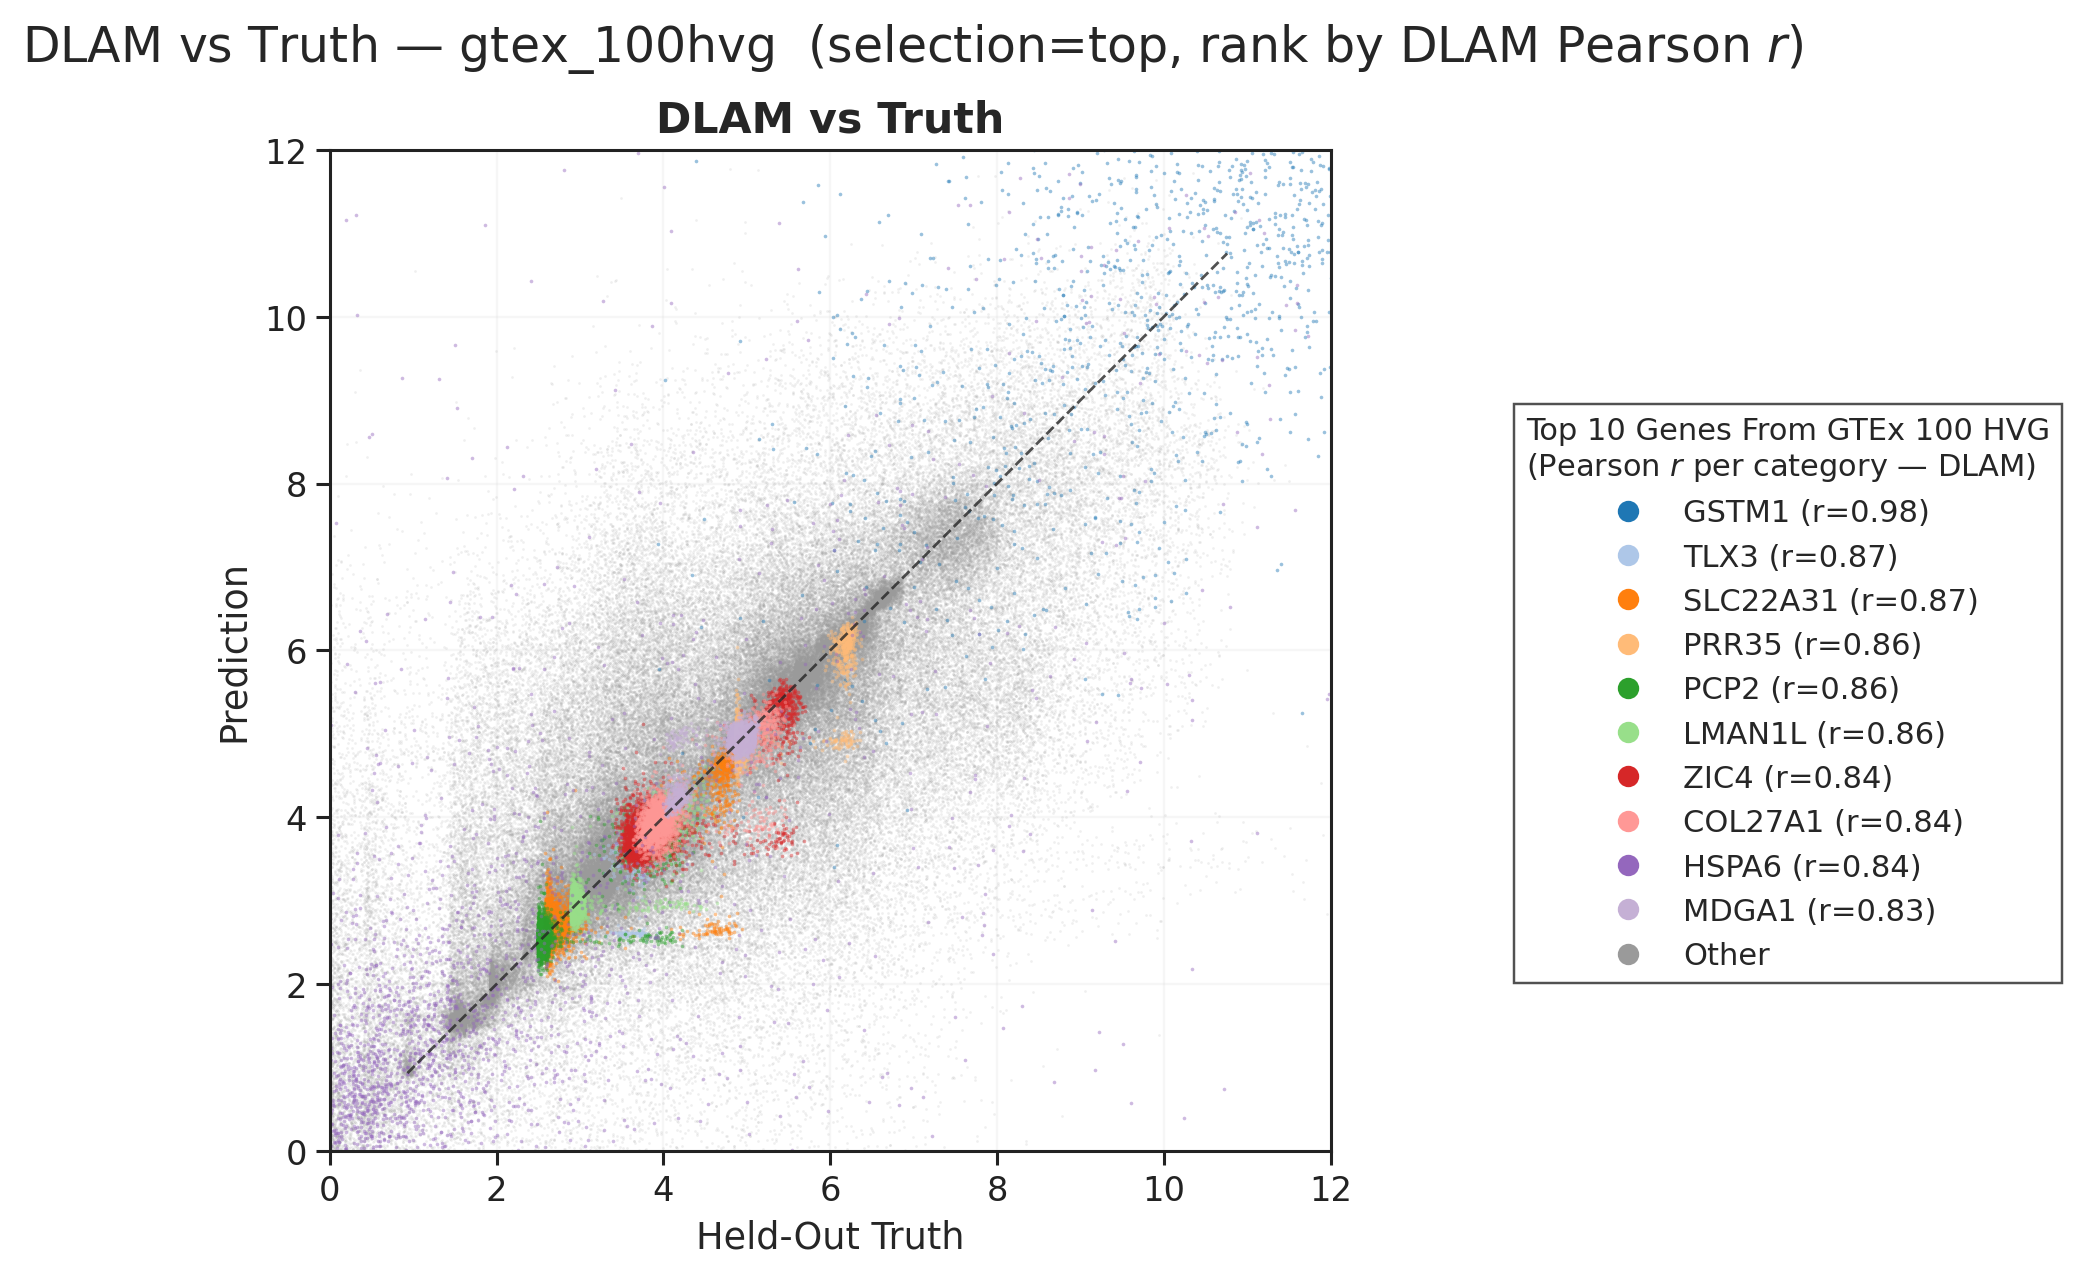

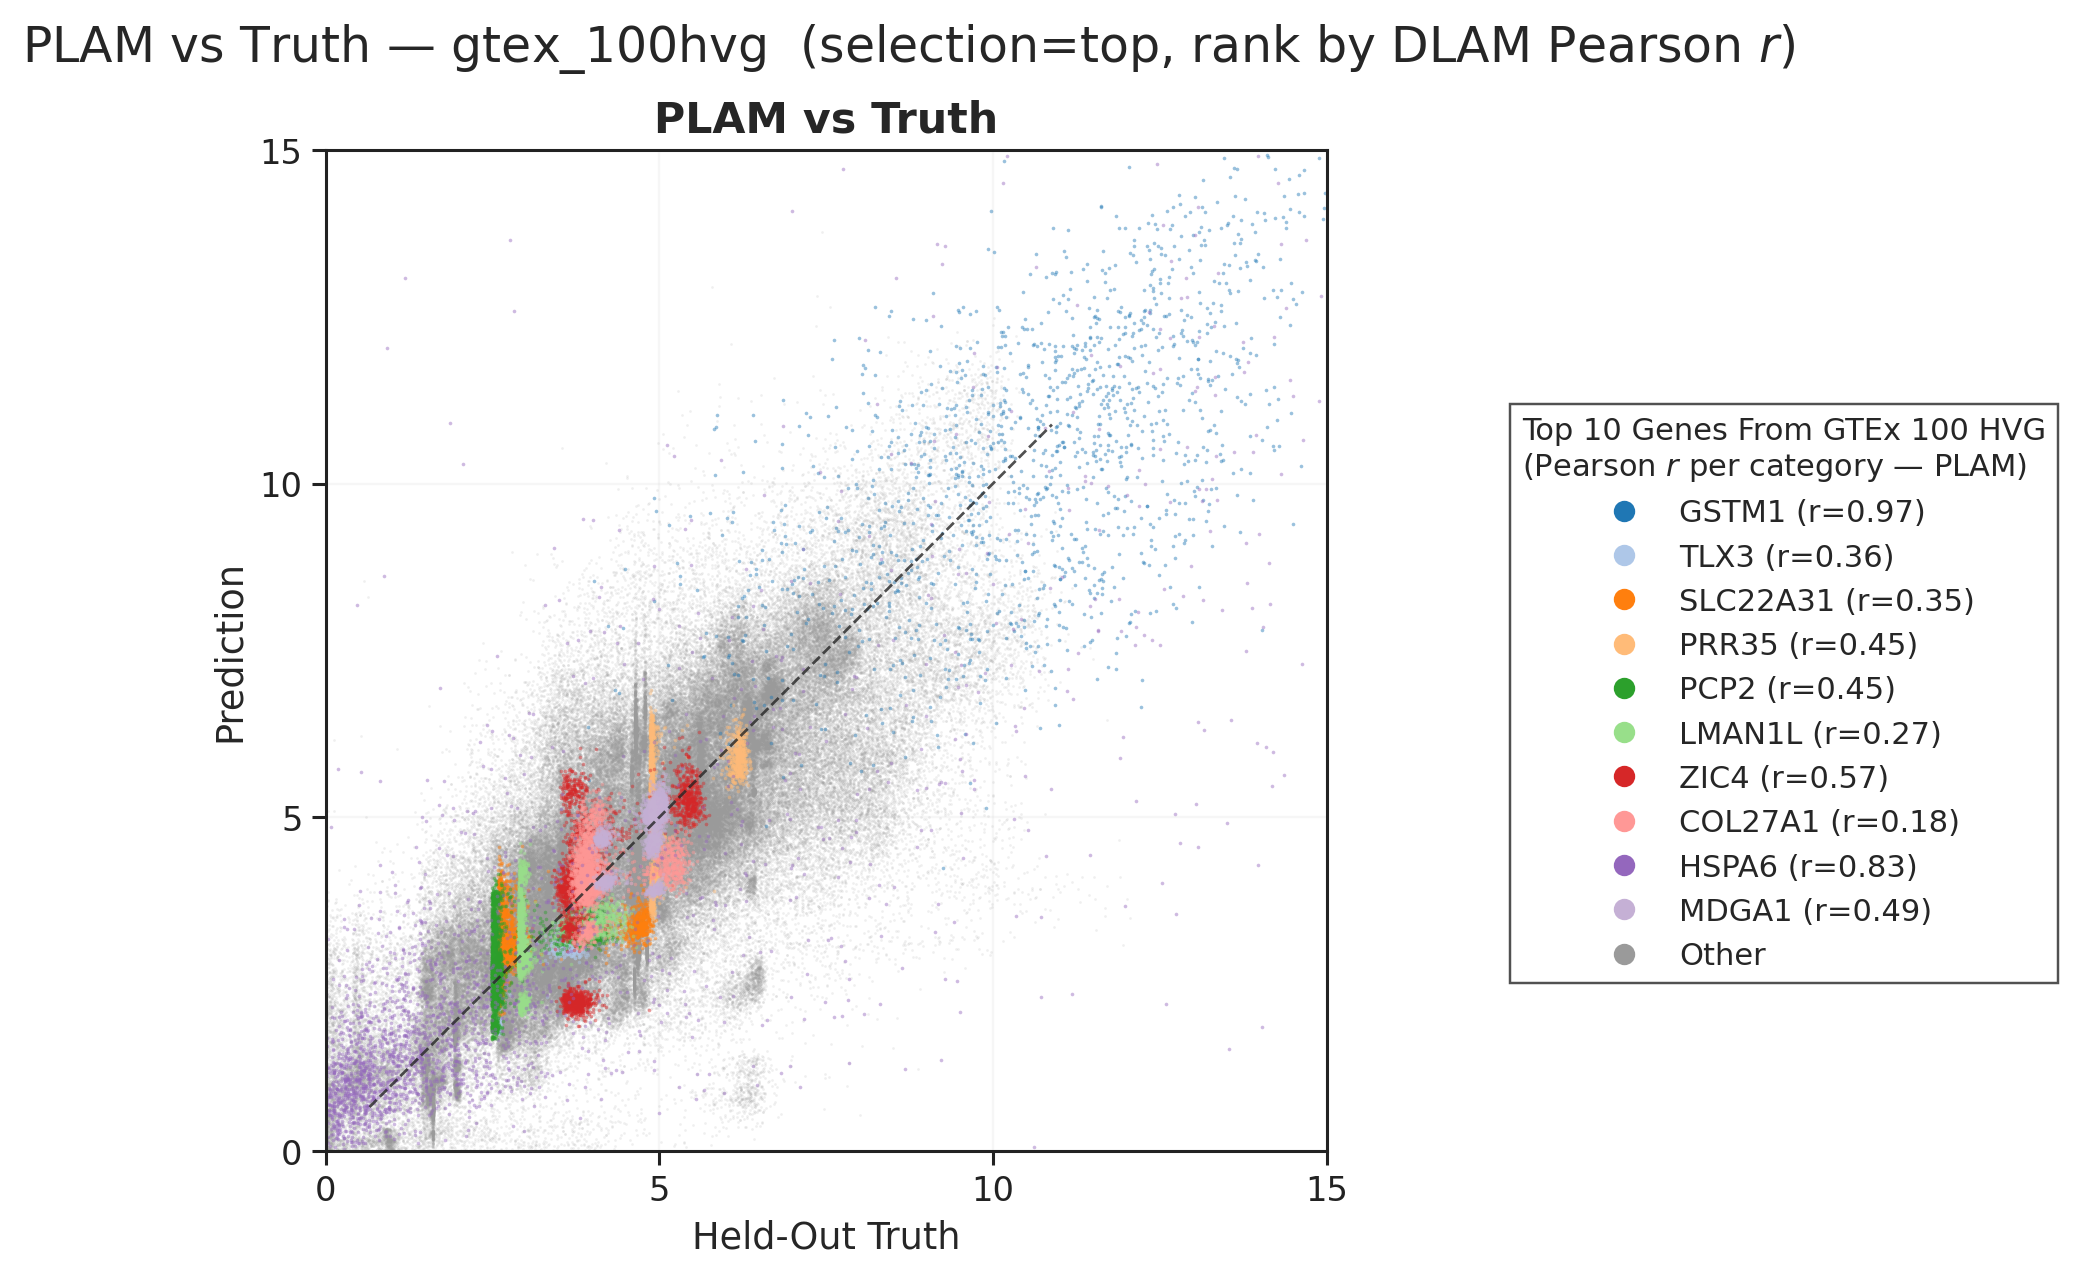

In [17]:
# One figure per model. The shared `sublist_rank_lookup` ensures all three panels
# color the same N genes for direct comparison.
for _model in MODELS:
    fig, axes = plot_global_prediction_scatter(
        build_panel_view(SUBLIST_GENE_LIST_PATH, models=[_model]),
        color_by='gene',
        top_n=SUBLIST_TOP_N,
        gene_selection=SUBLIST_SELECTION,
        gene_rank_lookup=sublist_rank_lookup,
        gene_rank_metric=SUBLIST_RANK_METRIC,
        highlight_genes=SUBLIST_HIGHLIGHT_GENES,
        figsize=SUBLIST_FIGSIZE,
        max_points_per_model=SCATTER_MAX_POINTS_PER_MODEL,
        annotate_metric_in_legend=SUBLIST_ANNOTATE_METRIC is not None,
        annotation_metric=SUBLIST_ANNOTATE_METRIC or 'pearson_r',
        random_seed=SUBLIST_RANDOM_SEED,
    )
    fig.suptitle(
        f"{model_label(_model)} vs Truth — {SUBLIST_GENE_LIST_PATH}  "
        f"(selection={SUBLIST_SELECTION}, rank by {model_label(SUBLIST_RANK_MODEL)} "
        f"{format_legend_label(SUBLIST_RANK_METRIC)})",
        fontsize=font_size('xxl'), y=0.97,
    )


## Section 4 — Interactive single-gene scatter

Pick a model and a gene from the configured panel; the scatter for **that gene only across all GTEx samples** renders below. Each point is one held-out subject-region observation; color = tissue.

Uses `ipywidgets` dropdowns (no `%matplotlib widget` / `ipympl` needed — every dropdown change just re-renders a regular inline figure). Re-render time is ~0.5–1 s per change.


In [18]:
# Section 4 config — interactive single-gene scatter
INTERACTIVE_GENE_LIST_PATH = SUBLIST_GENE_LIST_PATH   # reuse Section 3's panel by default
INTERACTIVE_COLOR_BY       = 'region'                 # tissue coloring on the per-gene scatter
INTERACTIVE_FIGSIZE        = (7.5, 6.5)
INTERACTIVE_DEFAULT_MODEL  = 'dlam'
INTERACTIVE_DEFAULT_GENE   = None                     # None = first alphabetically; or specify e.g. 'PVALB'


In [19]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

# Resolve the gene panel from the configured list once for the dropdown options.
_interactive_view = build_panel_view(INTERACTIVE_GENE_LIST_PATH)
_gene_options = sorted(_interactive_view['genes'])
_default_gene = (
    INTERACTIVE_DEFAULT_GENE
    if INTERACTIVE_DEFAULT_GENE and INTERACTIVE_DEFAULT_GENE in _gene_options
    else _gene_options[0]
)

# 'all' renders one figure with all 3 model panels; a specific model renders one panel.
_model_options = ['all'] + list(MODELS)
_default_model = INTERACTIVE_DEFAULT_MODEL if INTERACTIVE_DEFAULT_MODEL in _model_options else 'all'

_model_dd = widgets.Dropdown(options=_model_options, value=_default_model, description='Model:')
_gene_dd  = widgets.Dropdown(options=_gene_options, value=_default_gene, description='Gene:')
_out      = widgets.Output()

def _render(*, model, gene):
    selected_models = list(MODELS) if model == 'all' else [model]
    _out.clear_output(wait=True)
    with _out:
        sub_view = build_panel_view(None, models=selected_models, genes=[gene])
        figsize = (
            (INTERACTIVE_FIGSIZE[0] * len(selected_models), INTERACTIVE_FIGSIZE[1])
            if len(selected_models) > 1 else INTERACTIVE_FIGSIZE
        )
        fig, axes = plot_global_prediction_scatter(
            sub_view,
            color_by=INTERACTIVE_COLOR_BY,
            figsize=figsize,
            annotate_metric_in_legend=True,
            annotation_metric='pearson_r',
        )
        title_models = ', '.join(model_label(m) for m in selected_models)
        fig.suptitle(
            f"{title_models} vs Truth — gene = {gene}  ({INTERACTIVE_GENE_LIST_PATH})",
            fontsize=font_size('xxl'), y=0.97,
        )
        plt.show()

def _on_change(_change):
    _render(model=_model_dd.value, gene=_gene_dd.value)

_model_dd.observe(_on_change, names='value')
_gene_dd.observe(_on_change, names='value')

display(widgets.HBox([_model_dd, _gene_dd]), _out)
_render(model=_model_dd.value, gene=_gene_dd.value)   # initial render


Output()

## Section 5 — Within-subject spatial Kendall-τ

Within each brain, is each gene predicted with the right *spatial ordering* across that subject's covered regions? We compute one Kendall-τ per `(subject, gene, model)` between truth and prediction across the subject's regions, then aggregate two ways:

- **Per-gene** — median across subjects → "how spatially predictable is gene G across brains?" (x = gene)
- **Per-subject** — median across genes → "how spatially predictable is the whole transcriptome within subject S?" (x = subject)

Median is used as the y-axis aggregation (NaN-robust to constant-truth genes); raw τ values are kept in the long table for downstream work.

**Compute cost:** ~250 subjects × N genes × 3 models scipy.kendalltau calls. HVG-100 finishes in seconds; all-genes is several minutes. Disk cache makes reruns instant.


In [20]:
# Section 5 config — within-subject Kendall-τ
KENDALL_GENE_LIST_PATH    = None        # default: ALL genes (cached once; sublists subset from there)
KENDALL_MIN_REGIONS       = 5           # subjects with k_s < this are dropped
KENDALL_FORCE_REBUILD     = False       # bypass disk cache

# Plot knobs (shared across the gene-wise + subject-wise ranked views)
KENDALL_METRIC_COL        = 'median'    # 'median' (default) | 'mean'
KENDALL_ANCHOR_MODEL      = 'naive'
KENDALL_SPARSIFY          = 100
KENDALL_BOTTOM_QUANTILE   = None        # no bottom-tail red shading by default
KENDALL_TOP_QUANTILE      = None


In [21]:
# Build the gene-panel view (None → all genes), then compute (cached on disk).
kendall_view = build_panel_view(KENDALL_GENE_LIST_PATH)
print('kendall view: subjects =', kendall_view['truth_df']['subject'].nunique(),
      ' genes =', len(kendall_view['genes']))

kendall_long = compute_within_subject_kendall(
    kendall_view,
    models=MODELS,
    min_regions=KENDALL_MIN_REGIONS,
    force_rebuild=KENDALL_FORCE_REBUILD,
)
print('kendall_long:', kendall_long.shape)
display(
    kendall_long.groupby('model', as_index=False).agg(
        n_pairs=('kendall_tau', 'size'),
        n_valid=('kendall_tau', lambda s: int(s.notna().sum())),
        median_tau=('kendall_tau', 'median'),
        mean_tau=('kendall_tau', 'mean'),
    )
)


kendall view: subjects = 313  genes = 13618
[kendall_cache] miss notebooks/cache/genewise_kendall/ee75c5b0c87f5cfa.pkl — computing within-subject Kendall-τ...
   subjects: 313, genes: 13618, models: ['naive', 'dlam', 'plam'], min_regions=5
   [naive] 25 subjects processed (25 kept; 40s elapsed)
   [naive] 50 subjects processed (50 kept; 79s elapsed)
   [naive] 75 subjects processed (75 kept; 120s elapsed)
   [naive] 100 subjects processed (100 kept; 159s elapsed)
   [naive] 125 subjects processed (125 kept; 200s elapsed)
   [naive] 150 subjects processed (150 kept; 241s elapsed)
   [naive] 175 subjects processed (175 kept; 280s elapsed)
   [naive] 200 subjects processed (200 kept; 319s elapsed)
   [naive] 225 subjects processed (225 kept; 358s elapsed)
   [naive] 250 subjects processed (250 kept; 398s elapsed)
   [naive] 275 subjects processed (275 kept; 438s elapsed)
   [naive] 300 subjects processed (300 kept; 477s elapsed)
   [naive] 313 subjects kept (k ≥ 5), 0 skipped
   [dlam] 25

,model,n_pairs,n_valid,median_tau,mean_tau
0,dlam,4262434,4262434,0.142857,0.098261
1,naive,4262434,4262434,0.155556,0.145960
2,plam,4262434,4262434,0.066667,0.060103


In [29]:
kendall_per_gene    = summarize_kendall_per_unit(kendall_long, unit_col='gene')
kendall_per_subject = summarize_kendall_per_unit(kendall_long, unit_col='subject')
print('per-gene summary:   ', kendall_per_gene.shape)
print('per-subject summary:', kendall_per_subject.shape)
display(kendall_per_gene.head())
display(kendall_per_subject.head())

per-gene summary:    (40854, 7)
per-subject summary: (939, 7)


,model,gene,median,mean,std,n_subject,n_valid
0,dlam,A1BG,0.090909,0.068733,0.300934,313,313
1,dlam,A2M,0.000000,-0.029574,0.327421,313,313
2,dlam,A2ML1,0.127273,0.112274,0.270106,313,313
3,dlam,A3GALT2,0.142857,0.105869,0.309100,313,313
4,dlam,A4GALT,0.066667,0.020983,0.329293,313,313


,model,subject,median,mean,std,n_gene,n_valid
0,dlam,GTEX-1117F,-0.222222,-0.194855,0.266683,13618,13618
1,dlam,GTEX-111FC,0.018182,-0.006134,0.251240,13618,13618
2,dlam,GTEX-117XS,0.242424,0.208682,0.263646,13618,13618
3,dlam,GTEX-1192W,0.000000,0.032353,0.356253,13618,13618
4,dlam,GTEX-1192X,0.090909,0.084965,0.247591,13618,13618


### Gene-wise ranked (median Kendall-τ across subjects)

One x position per gene; the same gene occupies the same x position under every model since subjects are ordered by anchor model's median.


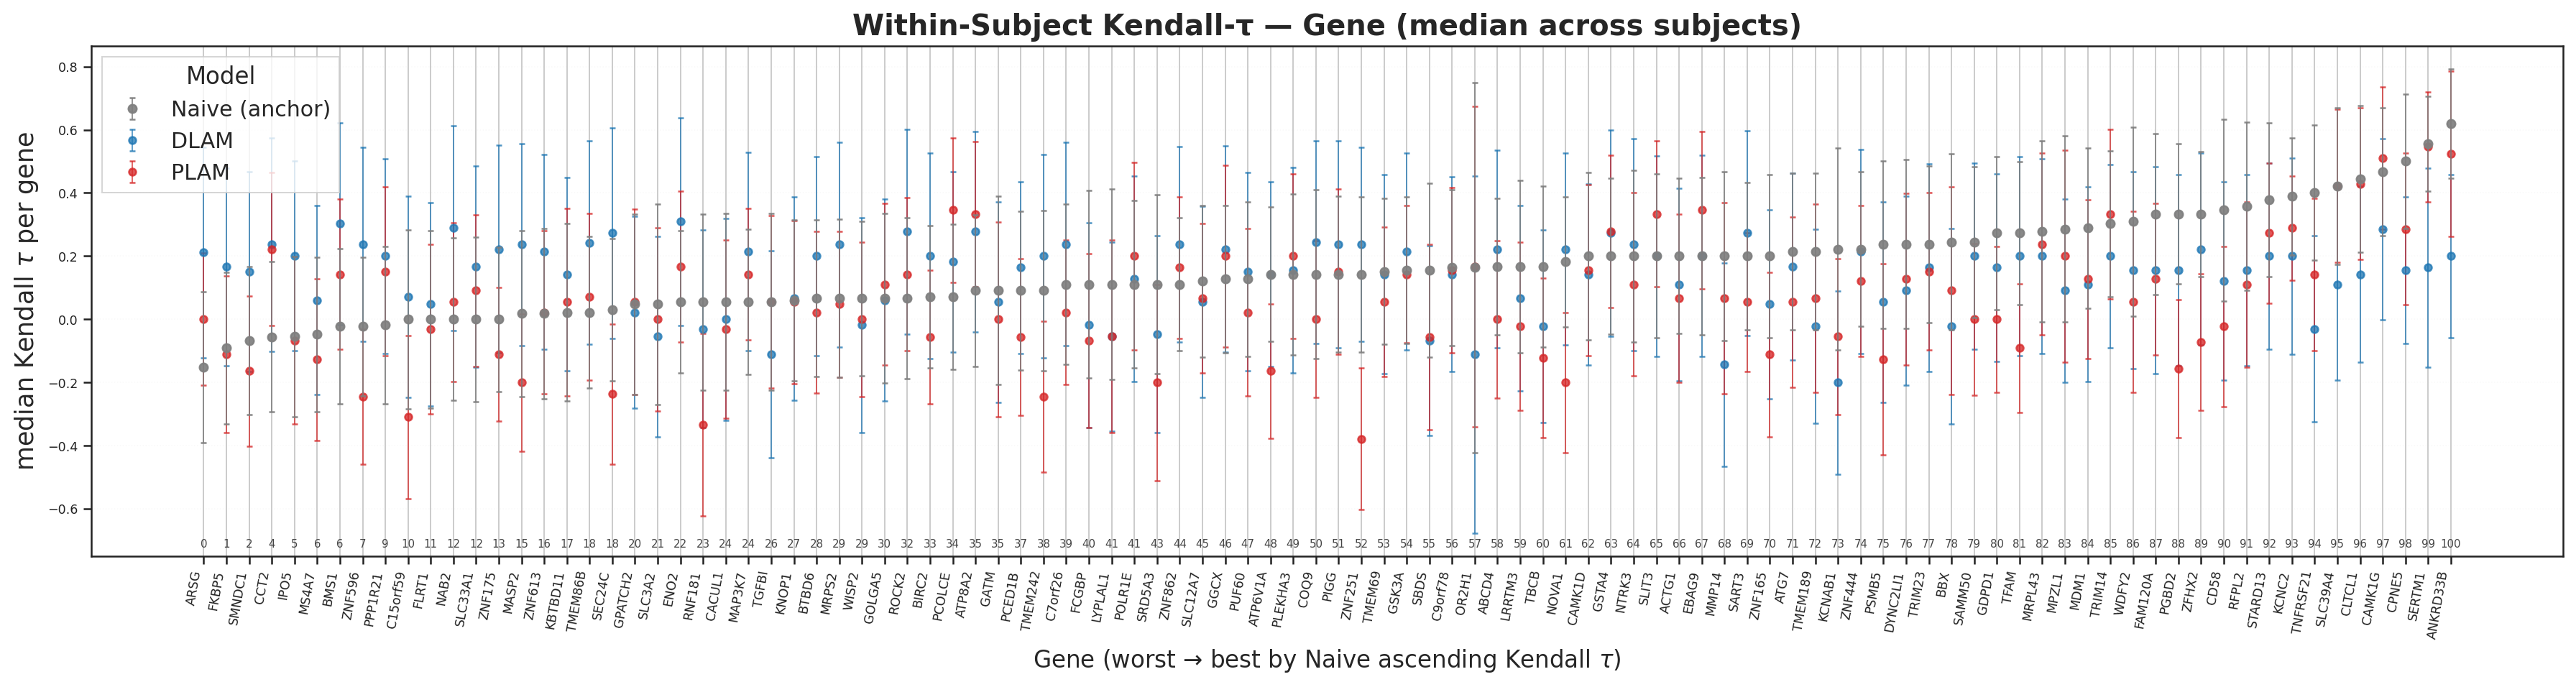

In [30]:
fig, ax, _ = plot_unitwise_kendall_ranked(
    kendall_per_gene,
    unit_col='gene',
    metric_col=KENDALL_METRIC_COL,
    models=MODELS,
    sparsify=KENDALL_SPARSIFY,
    anchor_model=KENDALL_ANCHOR_MODEL,
    bottom_quantile=KENDALL_BOTTOM_QUANTILE,
    top_quantile=KENDALL_TOP_QUANTILE,
)

### Subject-wise ranked (median Kendall-τ across genes)


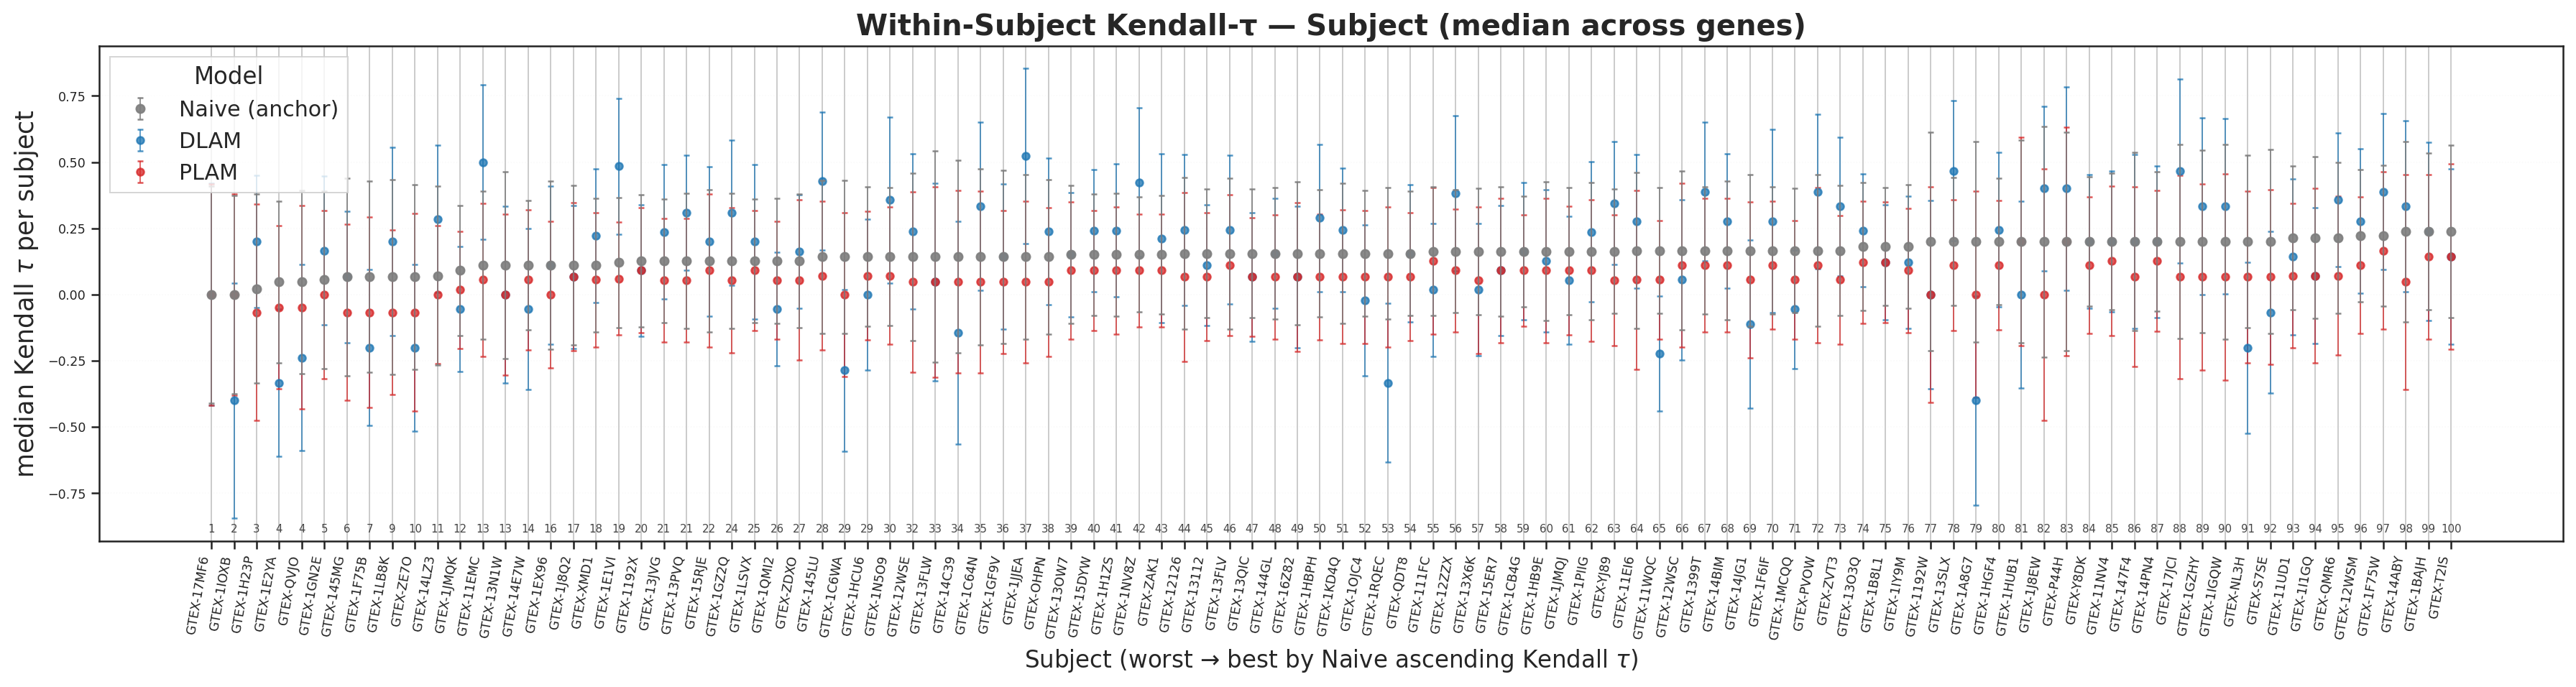

In [31]:
fig, ax, _ = plot_unitwise_kendall_ranked(
    kendall_per_subject,
    unit_col='subject',
    metric_col=KENDALL_METRIC_COL,
    models=MODELS,
    sparsify=KENDALL_SPARSIFY,
    anchor_model=KENDALL_ANCHOR_MODEL,
    bottom_quantile=KENDALL_BOTTOM_QUANTILE,
    top_quantile=KENDALL_TOP_QUANTILE,
)

### Sublist analysis (no recompute)

Filter the cached all-genes Kendall long table to a sublist (default: `gtex_100hvg`) via `filter_kendall_to_genes` and re-aggregate / re-plot. Free — no scipy calls.


In [32]:
# Kendall sublist config — repurposes the cached all-genes long table.
KENDALL_SUBLIST_PATH      = 'gtex_100hvg'   # any path/basename, or list of gene names
KENDALL_SUBLIST_SPARSIFY  = None            # smaller panels usually fit without sparsifying


In [33]:
# Resolve the sublist's gene names from the panel path.
_sublist_genes = list(build_panel_view(KENDALL_SUBLIST_PATH)['genes'])
kendall_long_sublist = filter_kendall_to_genes(kendall_long, _sublist_genes)
print(f'kendall_long_sublist: {kendall_long_sublist.shape}  ({len(_sublist_genes)} genes in panel)')

kendall_per_gene_sublist    = summarize_kendall_per_unit(kendall_long_sublist, unit_col='gene')
kendall_per_subject_sublist = summarize_kendall_per_unit(kendall_long_sublist, unit_col='subject')


kendall_long_sublist: (93900, 5)  (100 genes in panel)


#### Sublist gene-wise ranked


Text(0.5, 1.0, 'Within-Subject Kendall-τ — Gene (median across subjects)  (gtex_100hvg)')

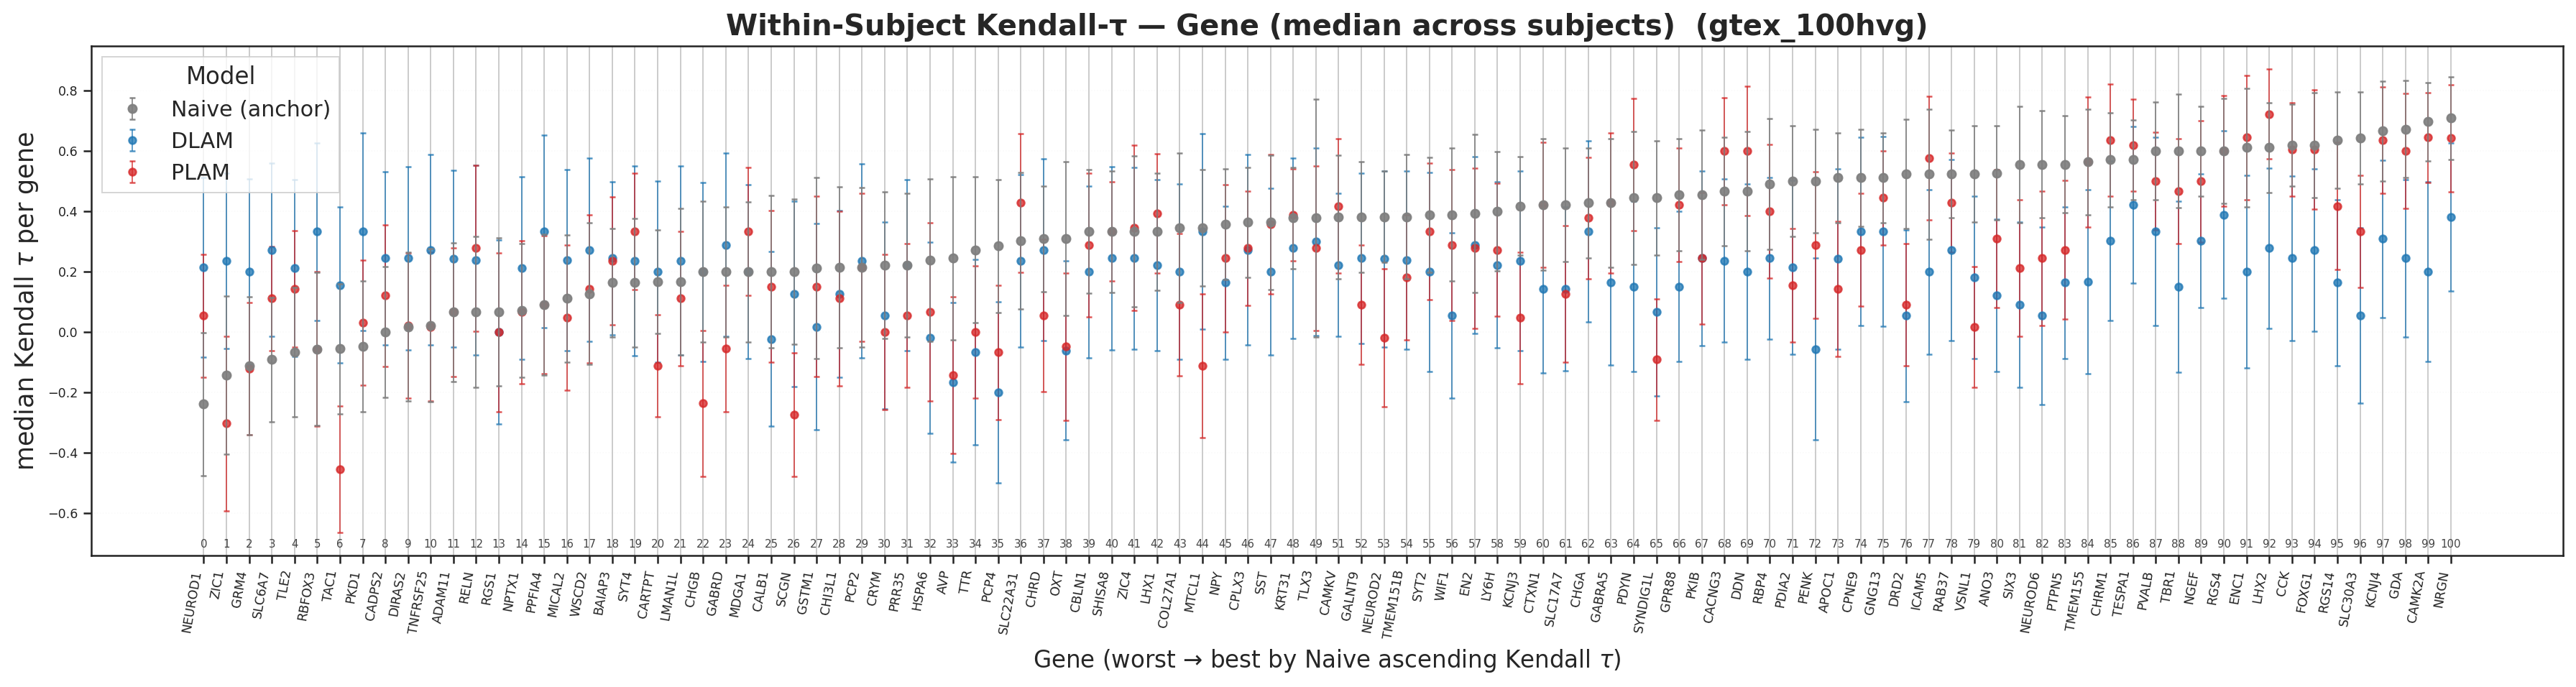

In [34]:
fig, ax, _ = plot_unitwise_kendall_ranked(
    kendall_per_gene_sublist,
    unit_col='gene',
    metric_col=KENDALL_METRIC_COL,
    models=MODELS,
    sparsify=KENDALL_SUBLIST_SPARSIFY,
    anchor_model=KENDALL_ANCHOR_MODEL,
    bottom_quantile=KENDALL_BOTTOM_QUANTILE,
    top_quantile=KENDALL_TOP_QUANTILE,
)
ax.set_title(
    f"{ax.get_title()}  ({KENDALL_SUBLIST_PATH})",
    fontsize=ax.title.get_fontsize(),
)


#### Sublist subject-wise ranked


Text(0.5, 1.0, 'Within-Subject Kendall-τ — Subject (median across genes)  (gtex_100hvg)')

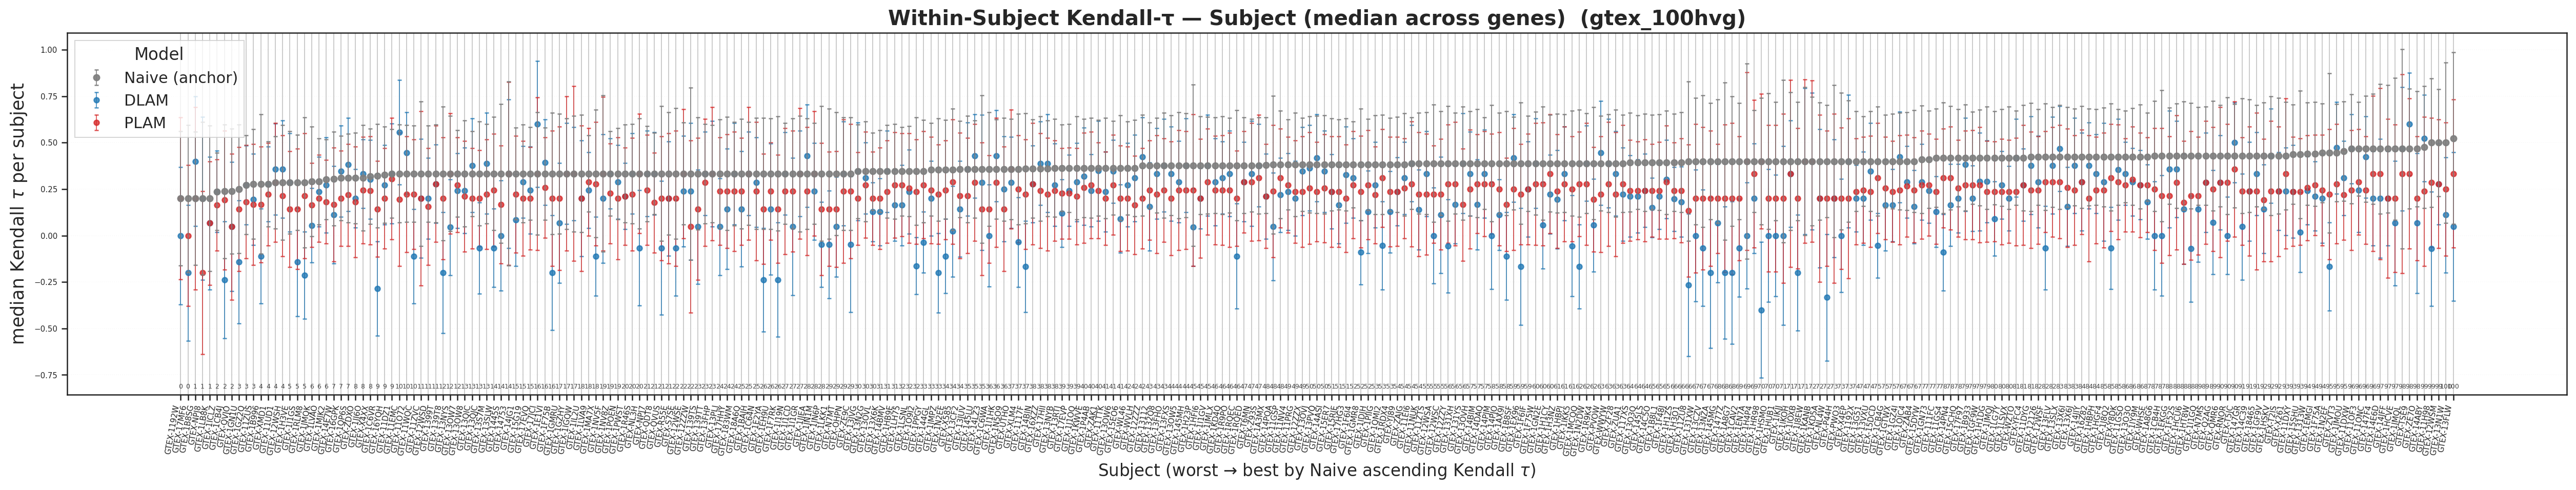

In [35]:
fig, ax, _ = plot_unitwise_kendall_ranked(
    kendall_per_subject_sublist,
    unit_col='subject',
    metric_col=KENDALL_METRIC_COL,
    models=MODELS,
    sparsify=KENDALL_SUBLIST_SPARSIFY,
    anchor_model=KENDALL_ANCHOR_MODEL,
    bottom_quantile=KENDALL_BOTTOM_QUANTILE,
    top_quantile=KENDALL_TOP_QUANTILE,
)
ax.set_title(
    f"{ax.get_title()}  ({KENDALL_SUBLIST_PATH})",
    fontsize=ax.title.get_fontsize(),
)
